# SE-LinOSS interactive inference

Load a checkpoint, run one test-set sample through the model, and inspect the result as a high-resolution spectrogram and inline audio playback. Mirrors `src/tasks/inference.py` but keeps everything in the notebook for quick iteration.

Run from the repo root: `uv run jupyter lab src/tasks/inference.ipynb`.

In [1]:
# GPU + memory selection. MUST run BEFORE any `import jax` — once JAX
# initializes its backend these env vars are ignored. If you change them
# after the imports cell has run, restart the kernel.
#
# By default JAX preallocates 75% of the visible GPU. If another process
# (e.g. a training run) already holds memory on that GPU you'll get
# CUDA_ERROR_OUT_OF_MEMORY at first allocation. Two ways out:
#   1. Pick a free GPU via CUDA_VISIBLE_DEVICES.
#   2. Disable preallocation so JAX grows on demand and shares the card.
import os

os.environ["CUDA_VISIBLE_DEVICES"] = "7"        # "" for CPU, "1", "0,1", ...
os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"   # grow on demand
# os.environ["XLA_PYTHON_CLIENT_MEM_FRACTION"] = "0.3"  # alternative: cap to 30%

In [2]:
import logging

logging.getLogger("jax").setLevel(logging.WARNING)

import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import Audio, display
from jax.scipy import signal as jsignal

from tasks.dataloader import get_vb_demand_dataloaders
from tasks.inference import _get_sample, _latest_ckpt, _load_inference_model
from tasks.train_util import infer

jax.config.update("jax_default_matmul_precision", "tensorfloat32")
jax.config.update("jax_compilation_cache_dir", "/data5/baur/linaxSE/.jax_cache")

## Parameters

Edit and re-run from here to try a different checkpoint or test sample.

In [21]:
CKPT_DIR = "/data5/baur/linaxSE/ckpts/latest"
CKPT_PATH = None  # explicit path overrides CKPT_DIR
SAMPLE_IDX = 100
SAMPLE_RATE = 16000
SEED = 0

# STFT params (32 ms window / 4 ms hop / 2048 nfft zero-pad) — the standard
# speech-analysis tradeoff: resolves harmonics without smearing phonemes.
NPERSEG = 512
NOVERLAP = 448
NFFT = 2048

In [22]:
ckpt_path = CKPT_PATH or _latest_ckpt(CKPT_DIR)
print(f"Loading checkpoint: {ckpt_path}")

key = jax.random.PRNGKey(SEED)
model, state = _load_inference_model(ckpt_path, key)

Loading checkpoint: /data5/baur/linaxSE/ckpts/latest/170001.eqx


In [23]:
_, test_loader = get_vb_demand_dataloaders(batch_size=1, num_workers=0)
item = _get_sample(test_loader, SAMPLE_IDX)

noisy = item["arrays"]["noisy"].numpy()
clean = item["arrays"]["clean"].numpy()
mask = item["arrays"]["mask"].numpy()
sample_id = item["meta"]["id"][0]
print(f"Sample: {sample_id}")

Sample: p232_105


In [24]:
output, _ = infer(model, noisy, state, key)
pred = np.asarray(output.prediction)

valid_len = int(mask[0, :, 0].sum())
noisy_wav = noisy[0, :valid_len, 0]
clean_wav = clean[0, :valid_len, 0]
pred_wav = pred[0, :valid_len, 0]

## Spectrogram comparison

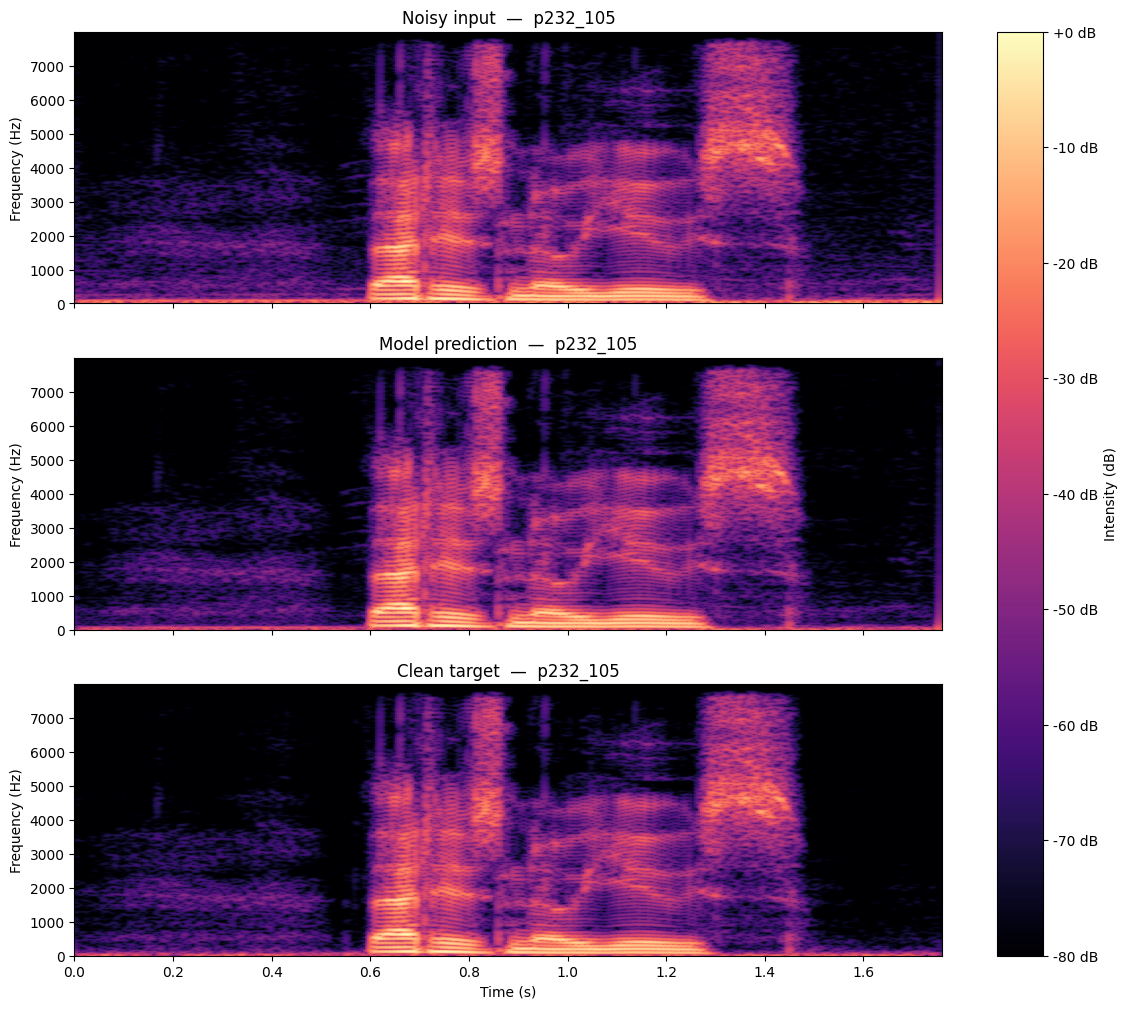

In [25]:
def stft_db(waveform):
    freqs, times, zxx = jsignal.stft(
        jnp.asarray(waveform),
        fs=SAMPLE_RATE,
        nperseg=NPERSEG,
        noverlap=NOVERLAP,
        nfft=NFFT,
    )
    mag = jnp.abs(zxx)
    s_db = 20 * jnp.log10(jnp.clip(mag, min=1e-10))
    s_db = s_db - jnp.max(s_db)
    return np.asarray(freqs), np.asarray(times), np.asarray(jnp.clip(s_db, min=-80))


fig, axes = plt.subplots(3, 1, figsize=(14, 12), sharex=True, sharey=True)
last_img = None
for ax, sig, title in zip(
    axes,
    (noisy_wav, pred_wav, clean_wav),
    ("Noisy input", "Model prediction", "Clean target"),
    strict=True,
):
    freqs, times, s_db = stft_db(sig)
    last_img = ax.imshow(
        s_db,
        aspect="auto",
        origin="lower",
        cmap="magma",
        interpolation=None,
        extent=[times[0], times[-1], freqs[0], freqs[-1]],
        vmin=-80,
        vmax=0,
    )
    ax.set_title(f"{title}  —  {sample_id}")
    ax.set_ylabel("Frequency (Hz)")
axes[-1].set_xlabel("Time (s)")
fig.colorbar(last_img, ax=axes, format="%+2.0f dB").set_label("Intensity (dB)")
plt.show()

## Audio playback

In [26]:
for label, wav in (("Noisy", noisy_wav), ("Predicted", pred_wav), ("Clean", clean_wav)):
    print(label)
    display(Audio(np.clip(wav, -1.0, 1.0), rate=SAMPLE_RATE, normalize=False))

Noisy


Predicted


Clean
